# Flight Delay Prediction — SkyWest Airlines
**ENSF 444 – Machine Learning Systems | Group 45**

This notebook builds and compares three classification models to predict whether a SkyWest flight
will arrive 15+ minutes late based on pre-departure information.

**Models compared:**
1. Logistic Regression (linear baseline)
2. Random Forest (non-linear ensemble)
3. XGBoost (non-linear boosting)

**Dataset:** U.S. Bureau of Transportation Statistics — SkyWest (OO) flights, January 2024

---

## 1. Imports and Data Loading

**How to run this notebook:**
1. Install dependencies: `pip install -r requirements.txt`
2. Ensure `data/skywest_flights.csv` exists in the repo root
3. Run all cells top to bottom from the `notebooks/` directory

In [24]:
# ── Standard libraries ──
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ──
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# use a pipeline that is compatible with imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation ──
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# ── Class imbalance ──
from imblearn.over_sampling import SMOTE

# ── Plot style ──
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Output directory for saved figures ──
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('All imports loaded successfully.')

All imports loaded successfully.


In [2]:
# ── Load the SkyWest dataset ──
# The CSV was pre-filtered from the Kaggle "Flight Delay Dataset 2018-2024"
# to only include flights operated by SkyWest Airlines (carrier code OO).
# Source: https://www.kaggle.com/datasets/shubhamsingh42/flight-delay-dataset-2018-2024

df = pd.read_csv('../data/skywest_flights.csv', low_memory=False)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df["FlightDate"].min()} to {df["FlightDate"].max()}')
df.head()

Dataset loaded: 56,811 rows x 120 columns
Date range: 2024-01-01 to 2024-01-31


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


---
## 2. Preprocessing

Based on findings from our EDA (`EDA/eda.ipynb`), we apply the following steps:
1. Drop cancelled/diverted flights (no arrival delay to predict)
2. Engineer the binary target variable (Delayed = ArrDelay >= 15 min)
3. Select features available before departure
4. Extract departure hour from scheduled departure time
5. Group rare airports into an "Other" category to reduce cardinality
6. One-hot encode categorical features (Origin, Dest)
7. Stratified 80/20 train-test split
8. Scale numerical features with StandardScaler
9. Apply SMOTE to handle class imbalance (75.9% on-time vs 24.1% delayed)

In [3]:
# ── Step 2.1: Remove cancelled/diverted flights ──
# These flights have no ArrDelay value, so they cannot be used for prediction.

print(f'Original rows: {len(df):,}')

# Drop cancelled flights
df = df[df['Cancelled'] == 0.0].copy()
print(f'After removing cancelled flights: {len(df):,}')

# Drop diverted flights
if 'Diverted' in df.columns:
    df = df[df['Diverted'] == 0.0].copy()
    print(f'After removing diverted flights: {len(df):,}')

# Drop any remaining rows with missing ArrDelay
df = df.dropna(subset=['ArrDelay']).copy()
print(f'After removing missing ArrDelay: {len(df):,}')

Original rows: 56,811
After removing cancelled flights: 54,430
After removing diverted flights: 54,206
After removing missing ArrDelay: 54,206


In [4]:
# ── Step 2.2: Engineer binary target variable ──
# A flight is considered "Delayed" if arrival delay is 15 minutes or more.
# This threshold aligns with the official BTS definition of a delayed flight.

df['Delayed'] = (df['ArrDelay'] >= 15).astype(int)

# Check class distribution
counts = df['Delayed'].value_counts()
pcts = df['Delayed'].value_counts(normalize=True) * 100

print('Target class distribution:')
print(f'  On-Time (0): {counts[0]:,} ({pcts[0]:.1f}%)')
print(f'  Delayed (1): {counts[1]:,} ({pcts[1]:.1f}%)')
print(f'  Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

Target class distribution:
  On-Time (0): 41,124 (75.9%)
  Delayed (1): 13,082 (24.1%)
  Imbalance ratio: 3.1:1


In [7]:
# ── Step 2.3: Select features ──
# We keep only features that are available BEFORE departure and useful for
# prediction. The 120-column dataset has 53 columns that are >=95% null
# (diversion fields, codeshare metadata) - we drop all of those.
#
# Features selected based on EDA findings:
#   - DayOfWeek: delay rates vary by day (Friday highest)
#   - DayofMonth: captures within-month patterns
#   - CRSDepTime: delay rates increase throughout the day
#   - CRSElapsedTime: scheduled flight duration
#   - Distance: flight distance in miles
#   - DepDelay: departure delay (strong predictor, but potential leakage)
#   - Origin, Dest: airport-level delay rate variation (7.7% to 46.5%)

features = ['DayOfWeek', 'DayofMonth', 'CRSDepTime', 'CRSElapsedTime',
            'Distance', 'DepDelay', 'Origin', 'Dest']

target = 'Delayed'

# Keep only selected columns
df_model = df[features + [target]].copy()

# Drop rows with missing DepDelay (small number from cancelled-adjacent records)
print(f'Rows before dropping missing DepDelay: {len(df_model):,}')
df_model = df_model.dropna(subset=['DepDelay']).copy()
print(f'Rows after: {len(df_model):,}')
print(f'\nFeatures selected: {features}')
print(f'Target: {target}')
df_model.head()

Rows before dropping missing DepDelay: 54,206
Rows after: 54,206

Features selected: ['DayOfWeek', 'DayofMonth', 'CRSDepTime', 'CRSElapsedTime', 'Distance', 'DepDelay', 'Origin', 'Dest']
Target: Delayed


,DayOfWeek,DayofMonth,CRSDepTime,CRSElapsedTime,Distance,DepDelay,Origin,Dest,Delayed
2,6,20,931,122.0,557.0,-8.0,PRC,DEN,0
3,6,20,1220,82.0,313.0,-6.0,DEN,GCC,0
4,6,20,1425,93.0,313.0,-10.0,GCC,DEN,0
5,6,20,1210,63.0,83.0,-6.0,DVL,JMS,0
6,6,20,928,42.0,61.0,-7.0,MCW,FOD,0


In [8]:
# ── Step 2.4: Feature engineering ──
# Extract departure hour from CRSDepTime (format: HHMM as integer).
# EDA showed delay rates increase throughout the day (cascading delays),
# so hour is more informative than the raw HHMM value.

df_model['DepHour'] = df_model['CRSDepTime'] // 100

# Drop the raw CRSDepTime since we now have DepHour
df_model = df_model.drop(columns=['CRSDepTime'])

print('Added DepHour feature (0-23), dropped raw CRSDepTime.')
print(f'DepHour distribution:\n{df_model["DepHour"].value_counts().sort_index()}')

Added DepHour feature (0-23), dropped raw CRSDepTime.
DepHour distribution:
DepHour
5     1314
6     3438
7     2894
8     3456
9     3299
10    4026
11    3494
12    3502
13    3931
14    3249
15    3558
16    3363
17    3734
18    3384
19    2946
20    1814
21    2089
22     611
23     104
Name: count, dtype: int64


In [9]:
# ── Step 2.5: Group rare airports ──
# The dataset has 236 unique origins and 235 unique destinations.
# Many airports have very few flights, which would create sparse one-hot columns.
# We keep airports with >= 100 flights and group the rest as "Other".

MIN_FLIGHTS = 100

# Group rare Origin airports
origin_counts = df_model['Origin'].value_counts()
frequent_origins = origin_counts[origin_counts >= MIN_FLIGHTS].index
df_model['Origin'] = df_model['Origin'].where(
    df_model['Origin'].isin(frequent_origins), 'Other'
)

# Group rare Dest airports
dest_counts = df_model['Dest'].value_counts()
frequent_dests = dest_counts[dest_counts >= MIN_FLIGHTS].index
df_model['Dest'] = df_model['Dest'].where(
    df_model['Dest'].isin(frequent_dests), 'Other'
)

print(f'Origin airports: {df_model["Origin"].nunique()} (rare grouped as "Other")')
print(f'Dest airports: {df_model["Dest"].nunique()} (rare grouped as "Other")')

Origin airports: 93 (rare grouped as "Other")
Dest airports: 94 (rare grouped as "Other")


In [10]:
# ── Step 2.6: One-hot encode categorical features ──
# Origin and Dest are nominal categorical variables with no inherent order,
# so one-hot encoding is the appropriate transformation.

df_model = pd.get_dummies(df_model, columns=['Origin', 'Dest'], drop_first=True)

print(f'Shape after one-hot encoding: {df_model.shape}')
print(f'Total features: {df_model.shape[1] - 1}')  # minus 1 for target column

Shape after one-hot encoding: (54206, 192)
Total features: 191


In [11]:
# ── Step 2.7: Train-test split ──
# 80/20 stratified split to preserve class distribution in both sets.

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Copy to avoid SettingWithCopyWarning when scaling in-place
X_train = X_train.copy()
X_test = X_test.copy()

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'\nTraining class distribution:')
print(f'  On-Time: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Delayed: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)')

Training set: 43,364 rows
Test set:     10,842 rows

Training class distribution:
  On-Time: 32,899 (75.9%)
  Delayed: 10,465 (24.1%)


In [12]:
# ── Step 2.8: Scale numerical features ──
# StandardScaler normalizes features to zero mean and unit variance.
# Required for Logistic Regression; tree-based models don't need it,
# but we apply it uniformly for pipeline consistency.
# We fit on training data only, then transform both sets (prevents leakage).

numerical_cols = ['DayOfWeek', 'DayofMonth', 'CRSElapsedTime',
                  'Distance', 'DepDelay', 'DepHour']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('Numerical features scaled with StandardScaler.')
print(f'Scaled columns: {numerical_cols}')
X_train.head()

Numerical features scaled with StandardScaler.
Scaled columns: ['DayOfWeek', 'DayofMonth', 'CRSElapsedTime', 'Distance', 'DepDelay', 'DepHour']


,DayOfWeek,DayofMonth,CRSElapsedTime,Distance,DepDelay,DepHour,Origin_ACV,Origin_AGS,Origin_ASE,Origin_ATL,...,Dest_SMF,Dest_SNA,Dest_STS,Dest_SUN,Dest_TUL,Dest_TUS,Dest_TYS,Dest_XNA,Dest_XWA,Dest_YUM
34330,0.093833,-1.340524,-1.027882,-1.314444,-0.379593,-0.005951,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12194,0.093833,-1.340524,1.149283,0.431359,-0.367103,1.088484,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30046,0.593464,-0.455040,-0.656171,-0.540897,-0.267181,-0.224838,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
44697,-0.405797,0.873186,-0.603069,-0.239285,-0.367103,-0.005951,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12934,-0.405797,-1.451209,0.989978,0.942326,-0.317142,0.650710,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# ── Step 2.9: Apply SMOTE to handle class imbalance ──
# The dataset is imbalanced (~76% on-time vs ~24% delayed).
# SMOTE generates synthetic minority-class samples to balance training.
# We only apply SMOTE to the TRAINING set - the test set stays untouched
# to reflect real-world class distribution during evaluation.

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {X_train.shape[0]:,} rows')
print(f'After SMOTE:  {X_train_smote.shape[0]:,} rows')
print(f'\nClass distribution after SMOTE:')
print(f'  On-Time: {(y_train_smote == 0).sum():,} ({(y_train_smote == 0).mean()*100:.1f}%)')
print(f'  Delayed: {(y_train_smote == 1).sum():,} ({(y_train_smote == 1).mean()*100:.1f}%)')

Before SMOTE: 43,364 rows
After SMOTE:  65,798 rows

Class distribution after SMOTE:
  On-Time: 32,899 (50.0%)
  Delayed: 32,899 (50.0%)


---
## 3. Model Training

We train all three models first with default hyperparameters (baseline),
then tune each one. Each team member is responsible for one model.

In [14]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model on the test set and return a dictionary of metrics.
    
    Parameters:
        model: trained sklearn-compatible classifier
        X_test: test feature matrix
        y_test: test labels
        model_name: string label for display
    
    Returns:
        dict with accuracy, precision, recall, f1, and roc_auc scores
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    print(f'\n-- {model_name} --')
    print(f'  Accuracy:  {metrics["Accuracy"]:.4f}')
    print(f'  Precision: {metrics["Precision"]:.4f}')
    print(f'  Recall:    {metrics["Recall"]:.4f}')
    print(f'  F1-Score:  {metrics["F1-Score"]:.4f}')
    print(f'  ROC-AUC:   {metrics["ROC-AUC"]:.4f}')
    
    return metrics

### 3.1 Logistic Regression (Linear Baseline)

In [17]:
# ── 3.1a Logistic Regression — Baseline (Default Hyperparameters) ──
# Serves as our baseline model. Fast to train, highly interpretable,
# and provides probability estimates. Establishes a performance floor
# against which the non-linear models are compared.
# Class imbalance is already handled by SMOTE on the training set.

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_smote, y_train_smote)
lr_metrics = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')


-- Logistic Regression --
  Accuracy:  0.9115
  Precision: 0.8221
  Recall:    0.8086
  F1-Score:  0.8153
  ROC-AUC:   0.9358


In [16]:
# ── 3.1b Logistic Regression — Hyperparameter Tuning (GridSearchCV) ──
# Tuning the regularization strength (C) and penalty type.
# solver='saga' supports both L1 and L2 penalties.
# Scoring on F1 since accuracy is misleading with imbalanced classes.
# 5-fold stratified cross-validation preserves class distribution in each fold.

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

lr_grid.fit(X_train_smote, y_train_smote)

print(f'Best LR params: {lr_grid.best_params_}')
print(f'Best LR CV F1:  {lr_grid.best_score_:.4f}')

lr_tuned = lr_grid.best_estimator_
lr_tuned_metrics = evaluate_model(lr_tuned, X_test, y_test, 'Logistic Regression (Tuned)')

Best LR params: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Best LR CV F1:  0.9025

-- Logistic Regression (Tuned) --
  Accuracy:  0.9118
  Precision: 0.8238
  Recall:    0.8074
  F1-Score:  0.8155
  ROC-AUC:   0.9347


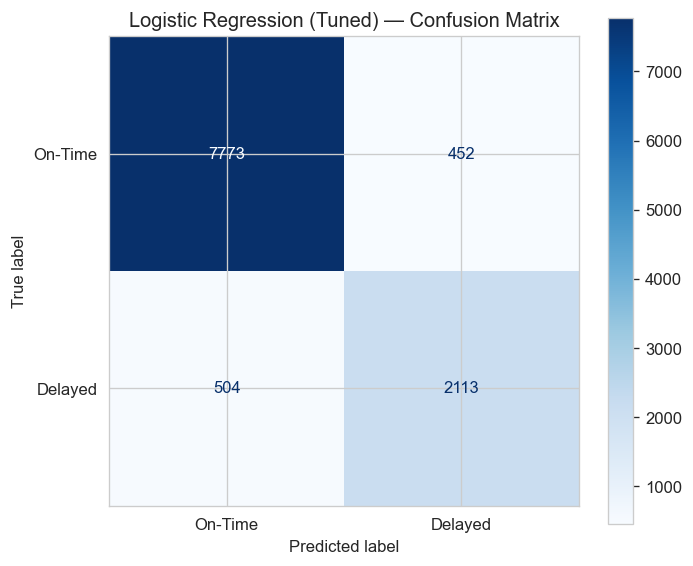

In [18]:
# ── 3.1c Logistic Regression — Confusion Matrix ──

fig, ax = plt.subplots(figsize=(6, 5))
y_pred_lr = lr_tuned.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['On-Time', 'Delayed'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Logistic Regression (Tuned) — Confusion Matrix')
plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/lr_confusion_matrix.png', dpi=150)
plt.show()

In [19]:
# ── 3.1d Logistic Regression — Classification Report ──

print('Logistic Regression (Tuned) — Classification Report')
print(classification_report(y_test, y_pred_lr, target_names=['On-Time', 'Delayed']))

Logistic Regression (Tuned) — Classification Report
              precision    recall  f1-score   support

     On-Time       0.94      0.95      0.94      8225
     Delayed       0.82      0.81      0.82      2617

    accuracy                           0.91     10842
   macro avg       0.88      0.88      0.88     10842
weighted avg       0.91      0.91      0.91     10842



### 3.2 Random Forest (Non-linear Ensemble)

TODO

In [25]:
# ── 3.2a Random Forest — Baseline ──
# TODO: Train Random Forest with default hyperparameters
# rf_model = RandomForestClassifier(...)
# rf_model.fit(X_train_smote, y_train_smote)
# rf_metrics = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_metrics = evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest')


-- Random Forest --
  Accuracy:  0.9168
  Precision: 0.8462
  Recall:    0.8009
  F1-Score:  0.8229
  ROC-AUC:   0.9442


In [26]:
# ── 3.2b Random Forest — Hyperparameter Tuning ──
# Use RandomizedSearchCV to tune RF hyperparameters
# rf_tuned_metrics = evaluate_model(rf_tuned, X_test, y_test, 'Random Forest (Tuned)')


# Random Forest pipeline tuning
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)

rf_tuned = rf_grid.best_estimator_

rf_tuned_metrics = evaluate_model(rf_tuned, X_test, y_test, 'Random Forest (Tuned)')

Best Random Forest parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}

-- Random Forest (Tuned) --
  Accuracy:  0.9167
  Precision: 0.8420
  Recall:    0.8063
  F1-Score:  0.8237
  ROC-AUC:   0.9464


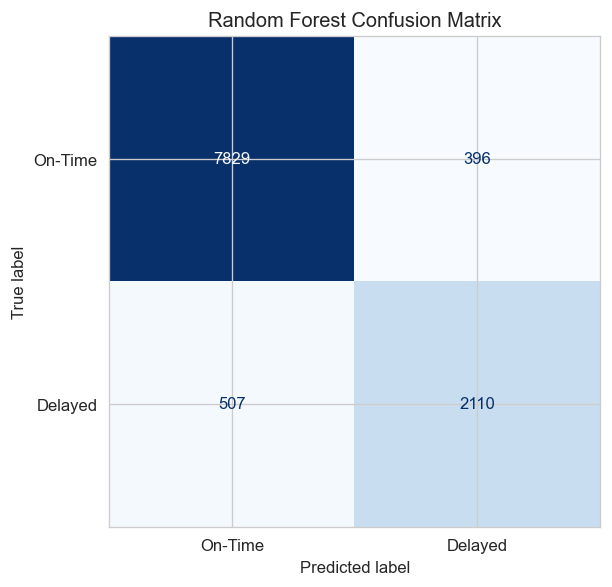

In [27]:
# Confusion Matrix - Random Forest Pipeline
y_pred_rf = rf_tuned.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['On-Time', 'Delayed'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()

fig.savefig(f'{RESULTS_DIR}/rf_confusion_matrix.png', dpi=150)
plt.show()

### 3.3 XGBoost (Non-linear Boosting)

TODO

In [ ]:
# ── 3.3a XGBoost — Baseline ──
# TODO: Train XGBoost with default hyperparameters
# xgb_model = XGBClassifier(...)
# xgb_model.fit(X_train_smote, y_train_smote)
# xgb_metrics = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

In [ ]:
# ── 3.3b XGBoost — Hyperparameter Tuning ──
# TODO: Use RandomizedSearchCV to tune XGBoost hyperparameters
# xgb_tuned_metrics = evaluate_model(xgb_tuned, X_test, y_test, 'XGBoost (Tuned)')

In [ ]:
# ── 3.3c XGBoost — Confusion Matrix & Classification Report ──
# TODO

---
## 4. Model Comparison

*TODO — combine all tuned model results into comparison table, ROC curves, and metrics bar chart once all three models are complete.*

In [ ]:
# ── 4.1 Final Comparison Table ──
# TODO: Uncomment once all three models are trained
# tuned_results = pd.DataFrame([lr_tuned_metrics, rf_tuned_metrics, xgb_tuned_metrics])
# tuned_results = tuned_results.set_index('Model')
# tuned_results.round(4)

In [ ]:
# ── 4.2 ROC Curves ──
# TODO: Plot ROC curves for all three tuned models on one figure

In [ ]:
# ── 4.3 Metrics Bar Chart ──
# TODO: Side-by-side bar chart comparing all metrics across models

---
## 5. DepDelay Leakage Experiment

*TODO — retrain all three models WITHOUT DepDelay to assess data leakage.*

EDA showed DepDelay correlates 0.98 with ArrDelay. This experiment compares
model performance with and without DepDelay to quantify the leakage impact.

In [ ]:
# ── 5.1 Rebuild features without DepDelay ──
# TODO

In [ ]:
# ── 5.2 Train models without DepDelay ──
# TODO

In [ ]:
# ── 5.3 Compare with vs without DepDelay ──
# TODO

---
## 6. Feature Importance and Final Summary

*TODO — feature importance plots and final recommendation.*

In [ ]:
# ── 6.1 Feature Importance ──
# TODO

In [ ]:
# ── 6.2 Final Summary ──
# TODO